In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

li_df = pd.read_csv(r"C:\Jeeva\multiple_disease_prediction\indian_liver_patient_csv.csv")
li_df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [7]:
#check for null and types
li_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [9]:
#replace column names in small case

li_df.columns = li_df.columns.str.lower()
li_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         583 non-null    int64  
 1   gender                      583 non-null    object 
 2   total_bilirubin             583 non-null    float64
 3   direct_bilirubin            583 non-null    float64
 4   alkaline_phosphotase        583 non-null    int64  
 5   alamine_aminotransferase    583 non-null    int64  
 6   aspartate_aminotransferase  583 non-null    int64  
 7   total_protiens              583 non-null    float64
 8   albumin                     583 non-null    float64
 9   albumin_and_globulin_ratio  579 non-null    float64
 10  dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [11]:
#replace null values
li_df['albumin_and_globulin_ratio'].fillna(li_df['albumin_and_globulin_ratio'].median(),inplace=True)
li_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         583 non-null    int64  
 1   gender                      583 non-null    object 
 2   total_bilirubin             583 non-null    float64
 3   direct_bilirubin            583 non-null    float64
 4   alkaline_phosphotase        583 non-null    int64  
 5   alamine_aminotransferase    583 non-null    int64  
 6   aspartate_aminotransferase  583 non-null    int64  
 7   total_protiens              583 non-null    float64
 8   albumin                     583 non-null    float64
 9   albumin_and_globulin_ratio  583 non-null    float64
 10  dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


C:\Users\JEEVA\AppData\Local\Temp\ipykernel_13952\1100496914.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  li_df['albumin_and_globulin_ratio'].fillna(li_df['albumin_and_globulin_ratio'].median(),inplace=True)


In [13]:
#check for outliers
li_df.describe()

,age,total_bilirubin,direct_bilirubin,alkaline_phosphotase,alamine_aminotransferase,aspartate_aminotransferase,total_protiens,albumin,albumin_and_globulin_ratio,dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [15]:
#check for objects to be encoded
li_df.dtypes

age                             int64
gender                         object
total_bilirubin               float64
direct_bilirubin              float64
alkaline_phosphotase            int64
alamine_aminotransferase        int64
aspartate_aminotransferase      int64
total_protiens                float64
albumin                       float64
albumin_and_globulin_ratio    float64
dataset                         int64
dtype: object

In [17]:
#convert gender column to numeric using label encoding
li_df['gender'] = li_df['gender'].str.strip().str.lower()  # remove whitespace, normalize
li_df['gender'] = li_df['gender'].map({'male': 1, 'female': 0})
li_df

,age,gender,total_bilirubin,direct_bilirubin,alkaline_phosphotase,alamine_aminotransferase,aspartate_aminotransferase,total_protiens,albumin,albumin_and_globulin_ratio,dataset
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [19]:
import pandas as pd

# Calculate correlation matrix
correlation_matrix = li_df.corr()
print(correlation_matrix)


                                 age    gender  total_bilirubin  \
age                         1.000000  0.056560         0.011763   
gender                      0.056560  1.000000         0.089291   
total_bilirubin             0.011763  0.089291         1.000000   
direct_bilirubin            0.007529  0.100436         0.874618   
alkaline_phosphotase        0.080425 -0.027496         0.206669   
alamine_aminotransferase   -0.086883  0.082332         0.214065   
aspartate_aminotransferase -0.019910  0.080336         0.237831   
total_protiens             -0.187461 -0.089121        -0.008099   
albumin                    -0.265924 -0.093799        -0.222250   
albumin_and_globulin_ratio -0.215968 -0.003184        -0.206015   
dataset                    -0.137351 -0.082416        -0.220208   

                            direct_bilirubin  alkaline_phosphotase  \
age                                 0.007529              0.080425   
gender                              0.100436           

In [53]:
#check columns relation to target before droping 
li_df.corr()['dataset'].sort_values(ascending=False)

dataset                       1.000000
albumin_and_globulin_ratio    0.162144
albumin                       0.161388
total_protiens                0.035008
gender                       -0.082416
age                          -0.137351
aspartate_aminotransferase   -0.151934
alamine_aminotransferase     -0.163416
alkaline_phosphotase         -0.184866
total_bilirubin              -0.220208
direct_bilirubin             -0.246046
Name: dataset, dtype: float64

In [21]:
#columns to drop
to_drop = ['direct_bilirubin','alamine_aminotransferase','total_protiens']
li_df = li_df.drop(columns=to_drop)

li_df.head()

,age,gender,total_bilirubin,alkaline_phosphotase,aspartate_aminotransferase,albumin,albumin_and_globulin_ratio,dataset
0,65,0,0.7,187,18,3.3,0.90,1
1,62,1,10.9,699,100,3.2,0.74,1
2,62,1,7.3,490,68,3.3,0.89,1
3,58,1,1.0,182,20,3.4,1.00,1
4,72,1,3.9,195,59,2.4,0.40,1


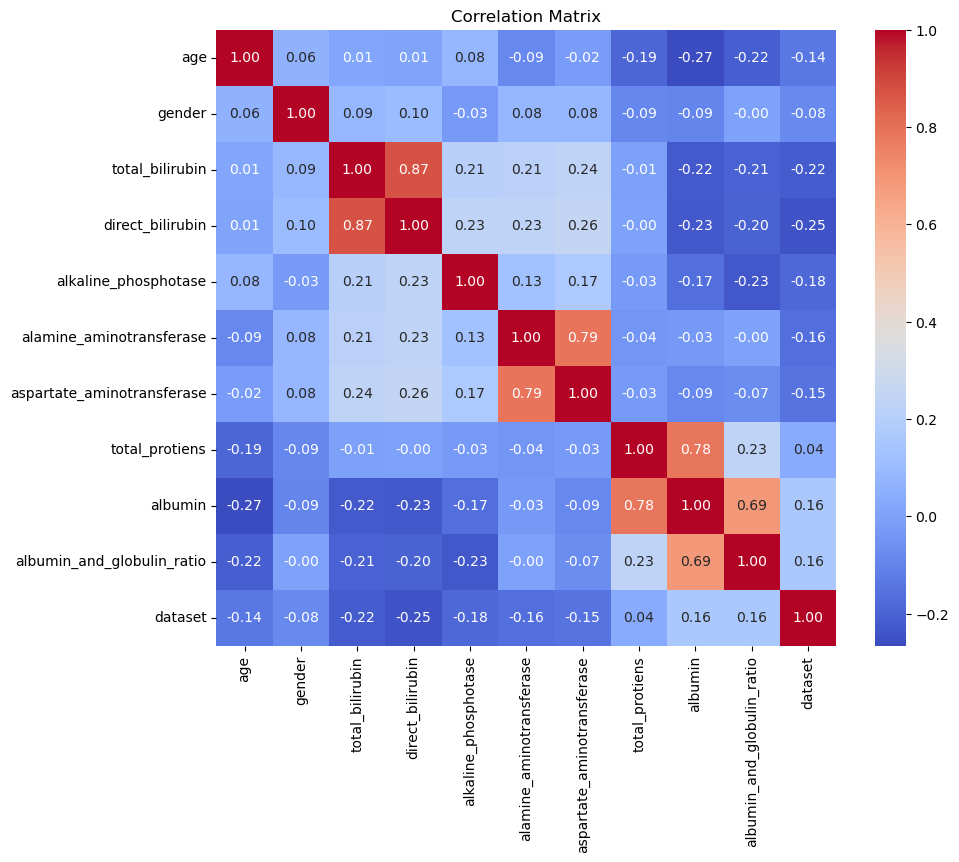

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot heatmap for correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Correlation Matrix")
plt.show()


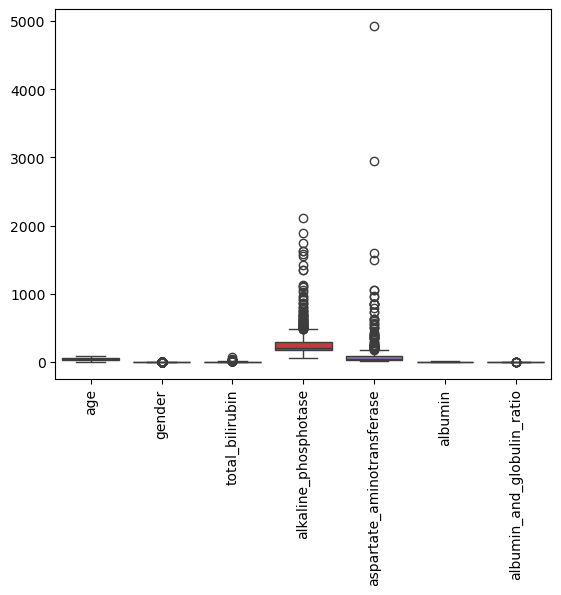

In [33]:
X = li_df.drop(columns=['dataset'])  # Features
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.show()


In [29]:
#check for imbalance
li_df['dataset'].value_counts(normalize=True)

dataset
1    0.713551
2    0.286449
Name: proportion, dtype: float64

Cross-validation scores: [0.70658683 0.71856287 0.62048193 0.62650602 0.81927711]
Mean CV accuracy: 0.6983

Classification Report:
              precision    recall  f1-score   support

           1       0.81      0.58      0.68       416
           2       0.67      0.87      0.76       416

    accuracy                           0.72       832
   macro avg       0.74      0.72      0.72       832
weighted avg       0.74      0.72      0.72       832


Confusion Matrix:


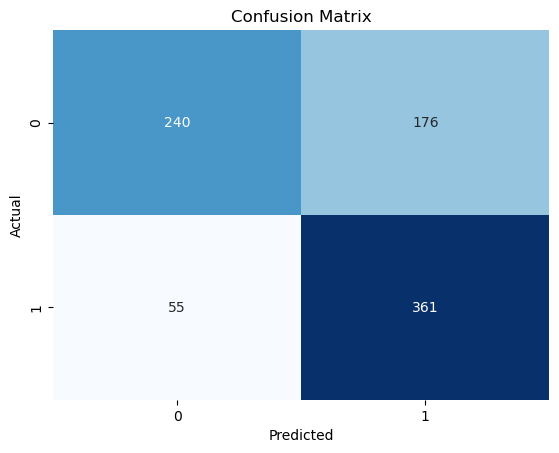

In [35]:
# Necessary imports
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Preprocess the data
X = li_df.drop(columns=['dataset'])  # Features
y = li_df['dataset']  # Target variable (0 or 1, classification)

# Step 2: Scale the features (optional but recommended for better SMOTE performance)

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


# Step 3: Apply SMOTE for oversampling the minority class
smote = SMOTE(sampling_strategy='auto', random_state=42)  # You can adjust 'sampling_strategy'
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Step 4: Train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)

# Step 5: Perform cross-validation
cv_scores = cross_val_score(model, X_resampled, y_resampled, cv=5, scoring='accuracy')

# Print cross-validation results
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")

# Step 6: Train the model on the full resampled data
model.fit(X_resampled, y_resampled)

# Step 7: Model evaluation (classification report and confusion matrix)
y_pred = model.predict(X_resampled)
print("\nClassification Report:")
print(classification_report(y_resampled, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_resampled, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Classification Report:
              precision    recall  f1-score   support

           1       0.77      0.57      0.66        40
           2       0.47      0.68      0.56        22

    accuracy                           0.61        62
   macro avg       0.62      0.63      0.61        62
weighted avg       0.66      0.61      0.62        62


Confusion Matrix:


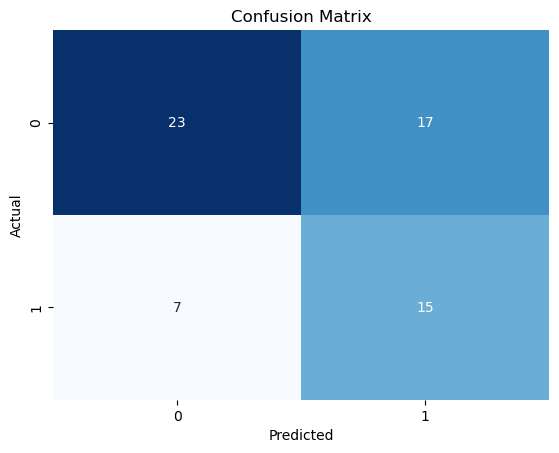

In [59]:
# Necessary imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: IQR-based outlier removal (only on features)
def remove_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    return df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Separate features and target
X = li_df.drop(columns='dataset')
y = li_df['dataset']

# Remove outliers from X only
X_clean = remove_outliers_iqr(X)
y_clean = y.loc[X_clean.index]

# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)

# Step 3: Robust scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Apply SMOTE only on training set
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Step 5: Train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_resampled, y_train_resampled)

# Step 6: Predict on test set
y_pred = model.predict(X_test_scaled)

# Step 7: Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Classification Report (Random Forest):
              precision    recall  f1-score   support

           1       0.74      0.80      0.77        40
           2       0.58      0.50      0.54        22

    accuracy                           0.69        62
   macro avg       0.66      0.65      0.65        62
weighted avg       0.69      0.69      0.69        62


Confusion Matrix:


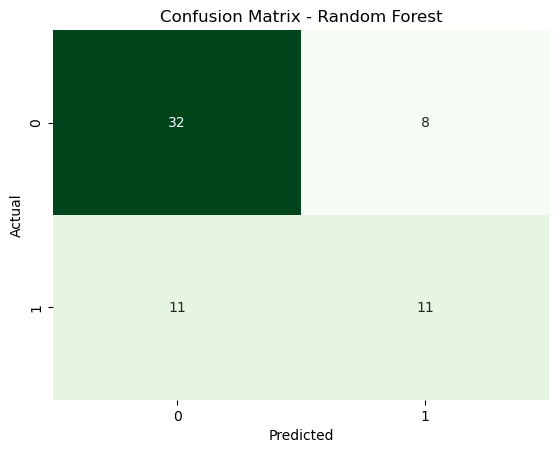

In [61]:
# Necessary imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: IQR-based outlier removal (features only)
def remove_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    return df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Separate features and target
X = li_df.drop(columns='dataset')
y = li_df['dataset']

# Remove outliers from features
X_clean = remove_outliers_iqr(X)
y_clean = y.loc[X_clean.index]

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)

# Step 3: Robust scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: SMOTE only on training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Step 5: Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Step 6: Predict on test set
y_pred = rf_model.predict(X_test_scaled)

# Step 7: Evaluation
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from xgboost import XGBClassifier

X = kid_df[top_10_features]
y = kid_df['classification']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Evaluate
y_pred = xgb_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))

# Save model
joblib.dump(xgb_model, 'kidney_model_xgboost_model.pkl')

Index(['age', 'gender', 'total_bilirubin', 'alkaline_phosphotase',
       'aspartate_aminotransferase', 'albumin', 'albumin_and_globulin_ratio'],
      dtype='object')


C:\Users\JEEVA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:25:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        40
           1       0.57      0.59      0.58        22

    accuracy                           0.69        62
   macro avg       0.67      0.67      0.67        62
weighted avg       0.70      0.69      0.70        62


Confusion Matrix:


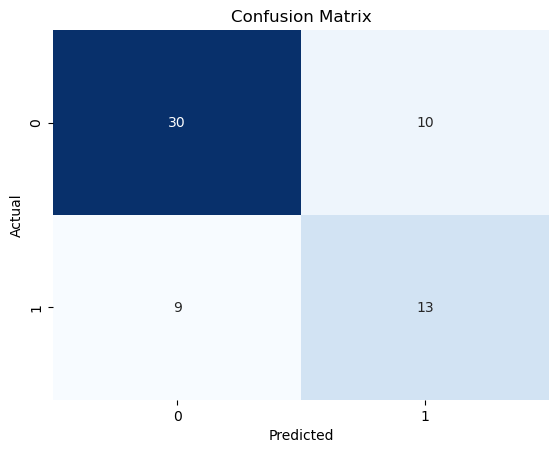

['liver_xgboost_model.pkl']

In [35]:
# Necessary imports
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Step 1: IQR-based outlier removal (only on features)
def remove_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    return df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Separate features and target
X = li_df.drop(columns='dataset')
y = li_df['dataset'].map({1: 0, 2: 1})
print(X.columns)

# Remove outliers from X only
X_clean = remove_outliers_iqr(X)
y_clean = y.loc[X_clean.index]

# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)

# Step 3: Robust scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Apply SMOTE only on training set
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Step 5:  Train XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_resampled, y_train_resampled)

# Step 6: Predict on test set
y_pred = xgb_model.predict(X_test_scaled)

# Step 7: Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Save model
joblib.dump(xgb_model, 'liver_xgboost_model.pkl')